In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import gc
from pathlib import Path
import netCDF4 as nc
from datetime import datetime
import re
from datetime import timedelta

In [2]:
gemlam_dir = "/results/forcing/atmospheric/GEM2.5/gemlam"
operational_dir = "/results/forcing/atmospheric/GEM2.5/operational"
time_fixed_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/TimeFixed"

gemlam_start = datetime(2007, 1, 3)
gemlam_end = datetime(2014, 9, 30)
ops_start = datetime(2014, 10, 1)
ops_end = datetime(2021, 12, 31)

years = range(2007, 2022)

fixed_filenames = {
    "gemlam_y2008m07d16.nc",
    "gemlam_y2008m07d17.nc",
    "gemlam_y2008m07d18.nc",
    "gemlam_y2008m07d19.nc",
    "gemlam_y2008m07d20.nc",
    "gemlam_y2008m07d21.nc",
    "gemlam_y2008m07d22.nc",
    "gemlam_y2008m07d23.nc",
    "gemlam_y2008m08d10.nc",
    "gemlam_y2008m08d11.nc",
    "gemlam_y2008m08d12.nc",
    "gemlam_y2012m10d04.nc"   
}

def get_file_date(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r"_y(\d{4})m(\d{2})d(\d{2})", filename)
    if match is None:
        return None
    year, month, day = map(int, match.groups())
    return datetime(year, month, day)

all_gemlam_files = glob.glob(os.path.join(gemlam_dir, "*.nc"))
all_ops_files = glob.glob(os.path.join(operational_dir, "ops_y????m??d??.nc"))

selected_gemlam_files = {}

for filepath in all_gemlam_files:
    file_date = get_file_date(filepath)
    if file_date is not None and gemlam_start <= file_date <= gemlam_end:
        selected_gemlam_files[file_date] = filepath

for filename in fixed_filenames:
    fixed_filepath = os.path.join(time_fixed_dir, filename)
    if not os.path.exists(fixed_filepath):
        raise FileNotFoundError(f"Corrected file not found: {fixed_filepath}")
    fixed_date = get_file_date(fixed_filepath)
    if fixed_date is None:
        raise ValueError(f"Could not extract date from: {fixed_filepath}")
    selected_gemlam_files[fixed_date] = fixed_filepath

selected_ops_files = {}

for filepath in all_ops_files:
    file_date = get_file_date(filepath)
    if file_date is not None and ops_start <= file_date <= ops_end:
        selected_ops_files[file_date] = filepath

all_selected_files = {**selected_gemlam_files, **selected_ops_files}

hrdps_files_by_year = {}

for year in years:
    files = [filepath for file_date, filepath in sorted(all_selected_files.items()) if file_date.year == year]
    if len(files) == 0:
        print(f"{year}: no files found")
        continue
    hrdps_files_by_year[year] = files
    print(year, ":", files[0], "to", files[-1], f"({len(files)} files)")

2007 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d03.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m12d31.nc (363 files)
2008 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m12d31.nc (366 files)
2009 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m12d31.nc (365 files)
2010 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m12d31.nc (365 files)
2011 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m12d31.nc (365 files)
2012 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m12d31.nc (366 files)
2013 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2013m01d01.nc to /results/forc

In [3]:
# Loading datasets

weights_pre_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
weights_post_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_22sep11onward.nc"
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"

ds_weights_pre = xr.open_dataset(weights_pre_file).load()
ds_weights_post = xr.open_dataset(weights_post_file).load()

with xr.open_dataset(mesh_mask_file) as ds_mesh:
    nemo_lat = ds_mesh["nav_lat"].load()
    nemo_lon = ds_mesh["nav_lon"].load()

In [4]:
# Converts hourly HRDPS longwave radiation from the 266 × 256 HRDPS grid to the 898 × 398 NEMO grid

transition_time = pd.Timestamp("2011-09-22 00:00:00")

def interpolate_therm_rad_with_weights(therm_rad, ds_weights):
    therm_rad = therm_rad.transpose("time_counter", "y", "x")

    n_time = therm_rad.sizes["time_counter"]
    source_shape = (therm_rad.sizes["y"],therm_rad.sizes["x"])
    n_source_cells = source_shape[0] * source_shape[1]

    source_values = (therm_rad.values.reshape(n_time, n_source_cells).astype(np.float32))
    target_shape = ds_weights["src01"].shape

    interpolated = np.zeros((n_time, target_shape[0], target_shape[1]),dtype=np.float32)

    for n in range(1, 5):
        # The source indexes in the weights file are 1-based
        source_index = (ds_weights[f"src{n:02d}"].values.astype(np.int64)- 1)
        weight = (ds_weights[f"wgt{n:02d}"].values.astype(np.float32))

        interpolated += (source_values[:, source_index]* weight[None, :, :])

    therm_rad_nemo = xr.DataArray(
        interpolated,
        dims=("time_counter", "y", "x"),
        coords={
            "time_counter": therm_rad["time_counter"],
            "nav_lat": (("y", "x"), nemo_lat.values),
            "nav_lon": (("y", "x"), nemo_lon.values),
        },
        name="therm_rad"
    )

    therm_rad_nemo.attrs = therm_rad.attrs.copy()
    therm_rad_nemo.attrs["grid"] = "SalishSeaCast NEMO grid"
    therm_rad_nemo.attrs["interpolation"] = (
        "Four-source weighted HRDPS-to-NEMO interpolation"
    )
    return therm_rad_nemo

In [5]:
# Open file and interpolates

def extract_and_interpolate_hourly_therm_rad(file):
    with xr.open_dataset(file) as ds:
        therm_rad = ds["therm_rad"].sortby("time_counter")
        time_index = therm_rad.get_index("time_counter")

        if time_index.has_duplicates:
            unique_mask = ~time_index.duplicated()
            therm_rad = therm_rad.isel(time_counter=unique_mask)

        therm_rad = therm_rad.load()

    times = pd.to_datetime(therm_rad["time_counter"].values)

    before_transition = times < transition_time
    after_transition = times >= transition_time

    pieces = []

    if before_transition.any():
        therm_rad_pre = therm_rad.isel(time_counter=np.where(before_transition)[0])
        interpolated_pre = interpolate_therm_rad_with_weights(therm_rad_pre,ds_weights_pre)
        pieces.append(interpolated_pre)

    if after_transition.any():
        therm_rad_post = therm_rad.isel(time_counter=np.where(after_transition)[0])
        interpolated_post = interpolate_therm_rad_with_weights(therm_rad_post,ds_weights_post)
        pieces.append(interpolated_post)

    therm_rad_nemo = xr.concat(pieces,dim="time_counter").sortby("time_counter")
    return therm_rad_nemo

In [6]:
sample_pre_file = hrdps_files_by_year[2008][0]
therm_rad_nemo_pre = extract_and_interpolate_hourly_therm_rad(sample_pre_file)

print("Shape:", therm_rad_nemo_pre.shape)
print("Time range:",therm_rad_nemo_pre.time_counter.values[0],"to",therm_rad_nemo_pre.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2008-01-01T00:00:00.000000000 to 2008-01-01T23:00:00.000000000


In [7]:
sample_post_file = hrdps_files_by_year[2012][0]
therm_rad_nemo_post = extract_and_interpolate_hourly_therm_rad(sample_post_file)

print("Shape:", therm_rad_nemo_post.shape)
print("Time range:",therm_rad_nemo_post.time_counter.values[0],"to",therm_rad_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2012-01-01T00:00:00.000000000 to 2012-01-01T23:00:00.000000000


In [8]:
sample_post_file = hrdps_files_by_year[2015][0]
therm_rad_nemo_post = extract_and_interpolate_hourly_therm_rad(sample_post_file)

print("Shape:", therm_rad_nemo_post.shape)
print("Time range:",therm_rad_nemo_post.time_counter.values[0],"to",therm_rad_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2015-01-01T00:00:00.000000000 to 2015-01-01T23:00:00.000000000


In [9]:
sample_post_file = hrdps_files_by_year[2021][-1]
therm_rad_nemo_post = extract_and_interpolate_hourly_therm_rad(sample_post_file)

print("Shape:", therm_rad_nemo_post.shape)
print("Time range:",therm_rad_nemo_post.time_counter.values[0],"to",therm_rad_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2021-12-31T00:00:00.000000000 to 2021-12-31T23:00:00.000000000


In [10]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (ds_mesh["tmask"].isel(t=0, z=0).load().values.astype(bool))
    nemo_lat_2d = ds_mesh["nav_lat"].load().values
    nemo_lon_2d = ds_mesh["nav_lon"].load().values
nemo_j, nemo_i = np.where(water_mask)
water_flat_indices = np.flatnonzero(water_mask.reshape(-1))
nemo_water_lat = nemo_lat_2d[water_mask]
nemo_water_lon = nemo_lon_2d[water_mask]
n_water = len(water_flat_indices)
print("NEMO grid shape:", water_mask.shape)
print("Number of surface water cells:", n_water)

NEMO grid shape: (898, 398)
Number of surface water cells: 81383


In [11]:
def process_daily_file_to_3h_water(file):
    therm_rad_nemo_hourly = extract_and_interpolate_hourly_therm_rad(file)
    n_time = therm_rad_nemo_hourly.sizes["time_counter"]

    therm_rad_water_values = (therm_rad_nemo_hourly.values.reshape(n_time, -1)[:, water_flat_indices].astype(np.float32))
    therm_rad_water_hourly = xr.DataArray(therm_rad_water_values,dims=("time_counter", "water_cell"),coords={
            "time_counter": therm_rad_nemo_hourly["time_counter"].values,
            "water_cell": np.arange(n_water, dtype=np.int32),},name="therm_rad",attrs=therm_rad_nemo_hourly.attrs,)

    therm_rad_water_3h = therm_rad_water_hourly.resample(time_counter="3h",label="left",closed="left",origin="start_day",).mean()
    return therm_rad_water_3h.load()

In [12]:
# # Run only once
# output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h"
# os.makedirs(output_dir, exist_ok=True)
# years = list(range(2007, 2022))
# hrdps_nemo_processed_files = []

# for year in years:
#     files = hrdps_files_by_year[year]
#     print(f"\nProcessing {year}: {len(files)} daily files")
#     daily_3h_results = []

#     for file_number, file in enumerate(files, start=1):
#         daily_3h = process_daily_file_to_3h_water(file)
#         daily_3h_results.append(daily_3h)

#         if file_number == 1 or file_number % 25 == 0 or file_number == len(files):
#             print(f"{year}: processed {file_number}/{len(files)} files")

#     therm_rad_year = xr.concat(daily_3h_results, dim="time_counter").sortby("time_counter")
#     time_index = therm_rad_year.get_index("time_counter")

#     if time_index.has_duplicates:
#         therm_rad_year = therm_rad_year.isel(time_counter=~time_index.duplicated())

#     ds_year = therm_rad_year.to_dataset(name="therm_rad")
#     ds_year = ds_year.assign_coords(nemo_j=("water_cell", nemo_j.astype(np.int32)), nemo_i=("water_cell", nemo_i.astype(np.int32)), nav_lat=("water_cell", nemo_water_lat.astype(np.float32)), nav_lon=("water_cell", nemo_water_lon.astype(np.float32)))
#     ds_year.attrs["description"] = "Raw hourly HRDPS therm_rad interpolated onto NEMO surface water cells, then resampled to three-hourly means."

#     output_file = f"{output_dir}/HRDPS_NEMO_{year}_therm_rad_3h.nc"
#     encoding = {"therm_rad": {"dtype": "float32", "zlib": True, "complevel": 4}}
#     ds_year.to_netcdf(output_file, engine="netcdf4", encoding=encoding)
#     hrdps_nemo_processed_files.append(output_file)

#     print("Saved:", output_file)
#     print("Shape:", ds_year["therm_rad"].shape)
#     print("Time range:", ds_year.time_counter.values[0], "to", ds_year.time_counter.values[-1])

#     del daily_3h_results
#     del therm_rad_year
#     del ds_year
#     gc.collect()

In [13]:
hrdps_nemo_files = sorted(glob.glob("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h/HRDPS_NEMO_*_therm_rad_3h.nc"))
ds_hrdps_nemo = xr.open_mfdataset(hrdps_nemo_files, combine="by_coords")
ds_hrdps_nemo = ds_hrdps_nemo.sortby("time_counter")

print(ds_hrdps_nemo)
print("Number of files:", len(hrdps_nemo_files))
print("First time:", ds_hrdps_nemo.time_counter.values[0])
print("Last time: ", ds_hrdps_nemo.time_counter.values[-1])
print("Shape:", ds_hrdps_nemo["therm_rad"].shape)

<xarray.Dataset> Size: 14GB
Dimensions:       (time_counter: 43816, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 351kB 2007-01-03 ... 2021-12-...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nemo_i        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lat       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lon       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
Data variables:
    therm_rad     (time_counter, water_cell) float32 14GB dask.array<chunksize=(363, 10173), meta=np.ndarray>
Attributes:
    description:  Raw hourly HRDPS therm_rad interpolated onto NEMO surface w...
Number of files: 15
First time: 2007-01-03T00:00:00.000000000
Last time:  2021-12-31T21:00:00.000000000
Shape: (43816, 81383)


In [14]:
train_years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
validation_years = [2007, 2008, 2009]
test_years = [2019, 2020, 2021]

In [15]:
ds_hrdps_train = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(train_years))
ds_hrdps_val = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(validation_years))
ds_hrdps_test = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(test_years))

In [16]:
canrcm_years = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
canrcm_rlds_files = []

for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_rlds.nc"))
    canrcm_rlds_files.append(matches[0])

print("CanRCM files:")
for file in canrcm_rlds_files:
    print(file)

CanRCM files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201301_201312_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201401_201412_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201501_201512_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201601_201612_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201701_201712_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201801_201812_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201901_201912_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_202001_202012_3h_

In [17]:
ds_canrcm = xr.open_mfdataset(canrcm_rlds_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
shifted_time = np.array([time_value - timedelta(hours=3)for time_value in ds_canrcm["time"].values])
ds_canrcm = ds_canrcm.assign_coords(time=("time", shifted_time))

print(ds_canrcm)
print("First timestamp:", ds_canrcm.time.values[0])
print("Last timestamp: ", ds_canrcm.time.values[-1])

/tmp/ipykernel_2600618/1147575100.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_rlds_files,combine="by_coords")


<xarray.Dataset> Size: 20GB
Dimensions:       (time: 43800, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 350kB 2007-01-01 00:00:00 ... 2021-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 701kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 44kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    rlds          (time, rlat, rlon) float32 20GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                  

In [18]:
nemo_water_lat = ds_hrdps_nemo["nav_lat"].values
nemo_water_lon = ds_hrdps_nemo["nav_lon"].values

nemo_water_lon_normalized = ((nemo_water_lon + 180) % 360) - 180

lat_min = float(np.nanmin(nemo_water_lat))
lat_max = float(np.nanmax(nemo_water_lat))

lon_min = float(np.nanmin(nemo_water_lon_normalized))
lon_max = float(np.nanmax(nemo_water_lon_normalized))

print("NEMO latitude range:", lat_min, "to", lat_max)
print("NEMO longitude range:", lon_min, "to", lon_max)

NEMO latitude range: 47.06300735473633 to 50.92766571044922
NEMO longitude range: -126.14797973632812 to -122.22117614746094


In [19]:
lat_canrcm = ds_canrcm["lat"]
lon_canrcm = ds_canrcm["lon"]

lon_canrcm_normalized = ((lon_canrcm + 180) % 360) - 180
canrcm_region_mask = ((lat_canrcm >= lat_min)& (lat_canrcm <= lat_max)
                      & (lon_canrcm_normalized >= lon_min) & (lon_canrcm_normalized <= lon_max))

rlat_indices, rlon_indices = np.where(canrcm_region_mask.values)

rlat_min = rlat_indices.min()
rlat_max = rlat_indices.max()

rlon_min = rlon_indices.min()
rlon_max = rlon_indices.max()

print("CanRCM rlat indices:", rlat_min, "to", rlat_max)
print("CanRCM rlon indices:", rlon_min, "to", rlon_max)

ds_canrcm_cut = (ds_canrcm[["rlds"]].isel(rlat=slice(rlat_min, rlat_max + 1),rlon=slice(rlon_min, rlon_max + 1)))
print(ds_canrcm_cut)

CanRCM rlat indices: 171 to 190
CanRCM rlon indices: 91 to 107
<xarray.Dataset> Size: 60MB
Dimensions:  (time: 43800, rlat: 20, rlon: 17)
Coordinates:
  * time     (time) object 350kB 2007-01-01 00:00:00 ... 2021-12-31 21:00:00
  * rlat     (rlat) float64 160B 2.51 2.73 2.95 3.17 ... 6.03 6.25 6.47 6.69
  * rlon     (rlon) float64 136B -19.25 -19.03 -18.81 ... -16.17 -15.95 -15.73
    lon      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
    lat      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
Data variables:
    rlds     (time, rlat, rlon) float32 60MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization

In [20]:
ds_canrcm_train = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(train_years))
ds_canrcm_val = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(validation_years))
ds_canrcm_test = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(test_years))

In [21]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")
    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")


def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = np.array([time_to_string(t)for t in ds_canrcm_split["time"].values])
    hrdps_times = np.array([time_to_string(t)for t in ds_hrdps_split["time_counter"].values])
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    return ds_canrcm_aligned, ds_hrdps_aligned

In [22]:
canrcm_times = np.array([time_to_string(time) for time in ds_canrcm_cut["time"].values])
hrdps_times = np.array([time_to_string(time) for time in ds_hrdps_nemo["time_counter"].values])

canrcm_not_in_hrdps = np.setdiff1d(canrcm_times, hrdps_times)
hrdps_not_in_canrcm = np.setdiff1d(hrdps_times, canrcm_times)

print("CanRCM timestamps not in HRDPS:", len(canrcm_not_in_hrdps))
print(canrcm_not_in_hrdps)

print("\nHRDPS timestamps not in CanRCM:", len(hrdps_not_in_canrcm))
print(hrdps_not_in_canrcm)

CanRCM timestamps not in HRDPS: 16
['2007-01-01 00:00:00' '2007-01-01 03:00:00' '2007-01-01 06:00:00'
 '2007-01-01 09:00:00' '2007-01-01 12:00:00' '2007-01-01 15:00:00'
 '2007-01-01 18:00:00' '2007-01-01 21:00:00' '2007-01-02 00:00:00'
 '2007-01-02 03:00:00' '2007-01-02 06:00:00' '2007-01-02 09:00:00'
 '2007-01-02 12:00:00' '2007-01-02 15:00:00' '2007-01-02 18:00:00'
 '2007-01-02 21:00:00']

HRDPS timestamps not in CanRCM: 32
['2008-02-29 00:00:00' '2008-02-29 03:00:00' '2008-02-29 06:00:00'
 '2008-02-29 09:00:00' '2008-02-29 12:00:00' '2008-02-29 15:00:00'
 '2008-02-29 18:00:00' '2008-02-29 21:00:00' '2012-02-29 00:00:00'
 '2012-02-29 03:00:00' '2012-02-29 06:00:00' '2012-02-29 09:00:00'
 '2012-02-29 12:00:00' '2012-02-29 15:00:00' '2012-02-29 18:00:00'
 '2012-02-29 21:00:00' '2016-02-29 00:00:00' '2016-02-29 03:00:00'
 '2016-02-29 06:00:00' '2016-02-29 09:00:00' '2016-02-29 12:00:00'
 '2016-02-29 15:00:00' '2016-02-29 18:00:00' '2016-02-29 21:00:00'
 '2020-02-29 00:00:00' '2020-02-29

In [23]:
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)

In [24]:
print("Validation:")
print("HRDPS:", ds_hrdps_val.sizes["time_counter"])
print("CanRCM:", ds_canrcm_val.sizes["time"])
print("Training:")
print("HRDPS:", ds_hrdps_train.sizes["time_counter"])
print("CanRCM:", ds_canrcm_train.sizes["time"])
print("Testing:")
print("HRDPS:", ds_hrdps_test.sizes["time_counter"])
print("CanRCM:", ds_canrcm_test.sizes["time"])

Validation:
HRDPS: 8744
CanRCM: 8744
Training:
HRDPS: 26280
CanRCM: 26280
Testing:
HRDPS: 8760
CanRCM: 8760


In [25]:
X_hrdps_train_raw = (ds_hrdps_train["therm_rad"].values.astype(np.float32))
X_hrdps_val_raw = (ds_hrdps_val["therm_rad"].values.astype(np.float32))
X_hrdps_test_raw = (ds_hrdps_test["therm_rad"].values.astype(np.float32))

print("Raw HRDPS-NEMO train:", X_hrdps_train_raw.shape)
print("Raw HRDPS-NEMO val:  ", X_hrdps_val_raw.shape)
print("Raw HRDPS-NEMO test: ", X_hrdps_test_raw.shape)

Raw HRDPS-NEMO train: (26280, 81383)
Raw HRDPS-NEMO val:   (8744, 81383)
Raw HRDPS-NEMO test:  (8760, 81383)


In [26]:
valid_fraction_hrdps = np.isfinite(X_hrdps_train_raw).mean(axis=0)
valid_nemo_cols = valid_fraction_hrdps > 0.95

X_hrdps_train = X_hrdps_train_raw[:, valid_nemo_cols].copy()
X_hrdps_val = X_hrdps_val_raw[:, valid_nemo_cols].copy()
X_hrdps_test = X_hrdps_test_raw[:, valid_nemo_cols].copy()

hrdps_col_mean = np.nanmean(X_hrdps_train,axis=0)

if not np.all(np.isfinite(hrdps_col_mean)):
    raise ValueError(
        "At least one retained NEMO cell has a non-finite training mean."
    )


def fill_with_training_mean(X, training_mean):
    X = X.copy()
    rows, cols = np.where(~np.isfinite(X))
    X[rows, cols] = training_mean[cols]
    return X


X_hrdps_train = fill_with_training_mean(X_hrdps_train,hrdps_col_mean)
X_hrdps_val = fill_with_training_mean(X_hrdps_val,hrdps_col_mean)
X_hrdps_test = fill_with_training_mean(X_hrdps_test,hrdps_col_mean)

print("Valid NEMO cells:", valid_nemo_cols.sum())
print("Final HRDPS train:", X_hrdps_train.shape)
print("Final HRDPS val:  ", X_hrdps_val.shape)
print("Final HRDPS test: ", X_hrdps_test.shape)

Valid NEMO cells: 81383
Final HRDPS train: (26280, 81383)
Final HRDPS val:   (8744, 81383)
Final HRDPS test:  (8760, 81383)


In [27]:
valid_water_cell = (ds_hrdps_train["water_cell"].values[valid_nemo_cols])
valid_nemo_j = (ds_hrdps_train["nemo_j"].values[valid_nemo_cols])
valid_nemo_i = (ds_hrdps_train["nemo_i"].values[valid_nemo_cols])
valid_nemo_lat = (ds_hrdps_train["nav_lat"].values[valid_nemo_cols])
valid_nemo_lon = (ds_hrdps_train["nav_lon"].values[valid_nemo_cols])
print("Saved coordinate count:", len(valid_water_cell))

Saved coordinate count: 81383


In [28]:
def make_canrcm_matrix(da):
    da = da.transpose("time", "rlat", "rlon")
    n_time = da.sizes["time"]
    return (da.values.reshape(n_time, -1).astype(np.float32))

X_canrcm_train_raw = make_canrcm_matrix(ds_canrcm_train["rlds"])
X_canrcm_val_raw = make_canrcm_matrix(ds_canrcm_val["rlds"])
X_canrcm_test_raw = make_canrcm_matrix(ds_canrcm_test["rlds"])

print("Raw CanRCM train:", X_canrcm_train_raw.shape)
print("Raw CanRCM val:  ", X_canrcm_val_raw.shape)
print("Raw CanRCM test: ", X_canrcm_test_raw.shape)

Raw CanRCM train: (26280, 340)
Raw CanRCM val:   (8744, 340)
Raw CanRCM test:  (8760, 340)


In [29]:
valid_fraction_canrcm = np.isfinite(X_canrcm_train_raw).mean(axis=0)
valid_canrcm_cols = valid_fraction_canrcm > 0.95

X_canrcm_train = X_canrcm_train_raw[:,valid_canrcm_cols].copy()
X_canrcm_val = X_canrcm_val_raw[:,valid_canrcm_cols].copy()
X_canrcm_test = X_canrcm_test_raw[:,valid_canrcm_cols].copy()
canrcm_col_mean = np.nanmean(X_canrcm_train,axis=0)

if not np.all(np.isfinite(canrcm_col_mean)):
    raise ValueError(
        "At least one retained CanRCM cell has a non-finite training mean."
    )

X_canrcm_train = fill_with_training_mean(X_canrcm_train,canrcm_col_mean)
X_canrcm_val = fill_with_training_mean(X_canrcm_val,canrcm_col_mean)
X_canrcm_test = fill_with_training_mean(X_canrcm_test,canrcm_col_mean)
print("Final CanRCM train:", X_canrcm_train.shape)
print("Final CanRCM val:  ", X_canrcm_val.shape)
print("Final CanRCM test: ", X_canrcm_test.shape)

Final CanRCM train: (26280, 340)
Final CanRCM val:   (8744, 340)
Final CanRCM test:  (8760, 340)


In [30]:
hrdps_variance_threshold = 0.98
max_hrdps_pcs = min(300,X_hrdps_train.shape[0] - 1,X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs,svd_solver="randomized",random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
threshold_indices = np.where(hrdps_cumulative_variance >= hrdps_variance_threshold)[0]
n_hrdps_pcs = threshold_indices[0] + 1
print("Selected HRDPS PCs:", n_hrdps_pcs)

Selected HRDPS PCs: 50


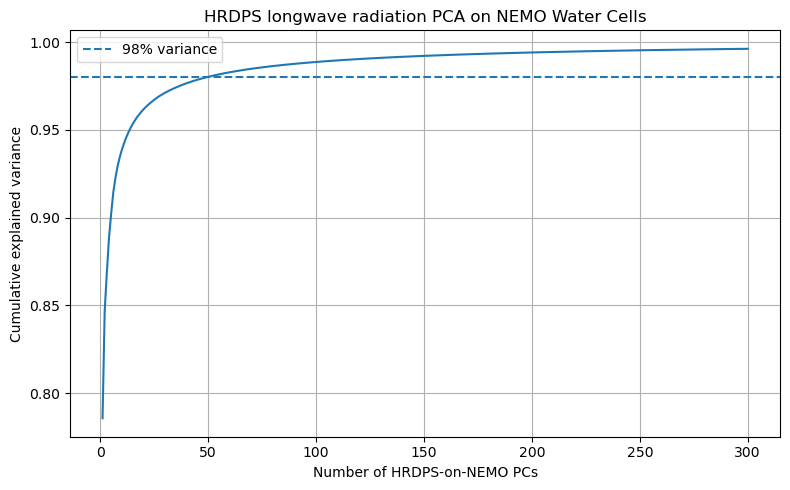

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1),hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold,linestyle="--",label="98% variance")
plt.xlabel("Number of HRDPS-on-NEMO PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS longwave radiation PCA on NEMO Water Cells")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]

print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:  ", hrdps_val_scores.shape)
print("HRDPS test scores: ", hrdps_test_scores.shape)

HRDPS train scores: (26280, 50)
HRDPS val scores:   (8744, 50)
HRDPS test scores:  (8760, 50)


In [33]:
max_canrcm_pcs = min(100,X_canrcm_train.shape[0] - 1,X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs,svd_solver="randomized",random_state=0)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

In [34]:
canrcm_pc_candidates = range(1,max_canrcm_pcs + 1)
val_r2_scores = []
for n_canrcm_pcs_candidate in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:,:n_canrcm_pcs_candidate]
    X_val_pc = canrcm_val_scores_all[:,:n_canrcm_pcs_candidate]
    model = LinearRegression()
    model.fit(X_train_pc,hrdps_train_scores)
    hrdps_val_scores_pred_candidate = model.predict(X_val_pc)
    val_r2 = r2_score(hrdps_val_scores,hrdps_val_scores_pred_candidate,multioutput="variance_weighted")
    val_r2_scores.append(val_r2)
val_r2_scores = np.array(val_r2_scores)

best_index = np.nanargmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]
best_val_r2 = val_r2_scores[best_index]

print("Best number of CanRCM PCs:", n_canrcm_pcs)

Best number of CanRCM PCs: 95


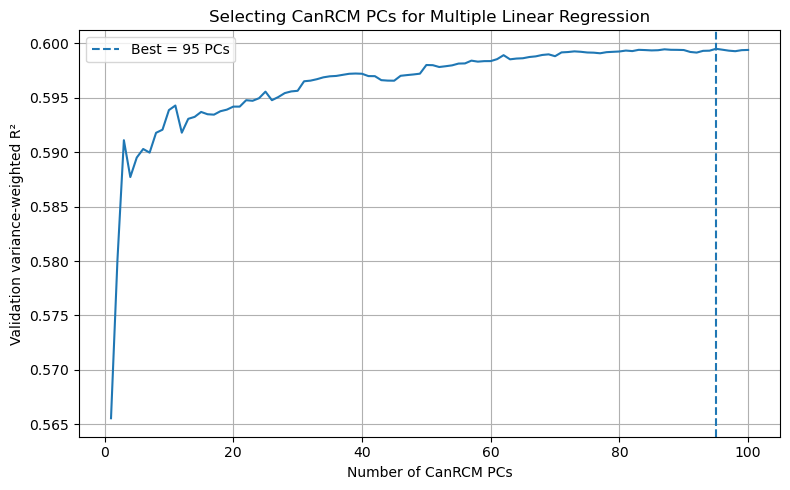

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates),val_r2_scores)
plt.axvline(n_canrcm_pcs,linestyle="--",label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting CanRCM PCs for Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
X_train_pc_final = canrcm_train_scores_all[:,:n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:,:n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:,:n_canrcm_pcs]

In [37]:
lr_model = LinearRegression()
lr_model.fit(X_train_pc_final,hrdps_train_scores)

hrdps_train_scores_pred = lr_model.predict(X_train_pc_final)
hrdps_val_scores_pred = lr_model.predict(X_val_pc_final)
hrdps_test_scores_pred = lr_model.predict(X_test_pc_final)

print("Regression coefficient shape:", lr_model.coef_.shape)
print("Predicted HRDPS train scores:",hrdps_train_scores_pred.shape)
print("Predicted HRDPS validation scores:",hrdps_val_scores_pred.shape)
print("Predicted HRDPS test scores:",hrdps_test_scores_pred.shape)

Regression coefficient shape: (50, 95)
Predicted HRDPS train scores: (26280, 50)
Predicted HRDPS validation scores: (8744, 50)
Predicted HRDPS test scores: (8760, 50)


In [38]:
def inverse_from_selected_hrdps_pcs(scores, pca, n_pcs):
    reconstructed = np.dot(scores,pca.components_[:n_pcs, :])
    reconstructed = reconstructed + pca.mean_
    return reconstructed.astype(np.float32)

In [39]:
X_hrdps_val_pred = inverse_from_selected_hrdps_pcs(hrdps_val_scores_pred,pca_hrdps,n_hrdps_pcs)
X_hrdps_test_pred = inverse_from_selected_hrdps_pcs(hrdps_test_scores_pred,pca_hrdps,n_hrdps_pcs)

In [40]:
def calculate_metrics(actual, predicted, label):
    rmse = np.sqrt(mean_squared_error(actual.ravel(),predicted.ravel()))
    mae = mean_absolute_error(actual.ravel(),predicted.ravel())
    bias = np.mean(predicted - actual)
    r2 = r2_score(actual,predicted,multioutput="variance_weighted")
    actual_std = np.std(actual, ddof=0)
    normalized_rmse = rmse / actual_std
    print(f"\n{label}")
    print("RMSE:", rmse)
    print("MAE: ", mae)
    print("Bias:", bias)
    print("R^2:  ", r2)
    print("Actual standard deviation:", actual_std)
    print("Normalized RMSE:", normalized_rmse)
    print("Normalized RMSE (%):", normalized_rmse * 100)
    return {"RMSE": rmse,"MAE": mae,"Bias": bias,"R2": r2, "Normalized_RMSE": normalized_rmse,"Normalized_RMSE_percent": normalized_rmse * 100}

In [41]:
val_metrics = calculate_metrics(X_hrdps_val, X_hrdps_val_pred, "Validation metrics on NEMO water cells")
test_metrics = calculate_metrics(X_hrdps_test,X_hrdps_test_pred,"Test metrics on NEMO water cells")


Validation metrics on NEMO water cells
RMSE: 22.82715042195847
MAE:  17.687402725219727
Bias: -4.5878377
R^2:   0.5856443047523499
Actual standard deviation: 35.687325
Normalized RMSE: 0.639643086907636
Normalized RMSE (%): 63.9643086907636

Test metrics on NEMO water cells
RMSE: 21.404868511534794
MAE:  15.773553848266602
Bias: 3.229827
R^2:   0.691766619682312
Actual standard deviation: 38.843338
Normalized RMSE: 0.5510563614419276
Normalized RMSE (%): 55.10563614419276


In [42]:
def nemo_vector_to_map(vector):
    nemo_map = np.full(water_mask.shape,np.nan,dtype=np.float32)
    nemo_map[valid_nemo_j,valid_nemo_i] = vector
    return nemo_map

In [43]:
def plot_actual_predicted_error(time_index,X_actual,X_predicted,times):
    actual_map = nemo_vector_to_map(X_actual[time_index])
    predicted_map = nemo_vector_to_map(X_predicted[time_index])
    error_map = predicted_map - actual_map
    temp_min = np.nanmin(np.stack([actual_map, predicted_map]))
    temp_max = np.nanmax(np.stack([actual_map, predicted_map]))
    error_limit = np.nanmax(np.abs(error_map))
    timestamp = pd.Timestamp(times[time_index])
    fig, axes = plt.subplots(1,3,figsize=(12, 8))

    p0 = axes[0].pcolormesh(actual_map,shading="auto",vmin=temp_min,vmax=temp_max)
    axes[0].set_title(f"Actual HRDPS on NEMO Grid\n{timestamp}")
    plt.colorbar(p0,ax=axes[0],label="Longwave Radiation")

    p1 = axes[1].pcolormesh(predicted_map,shading="auto",vmin=temp_min,vmax=temp_max )
    axes[1].set_title(f"Predicted PCA + MLR\n{timestamp}")
    plt.colorbar(p1,ax=axes[1],label="Temperture")

    p2 = axes[2].pcolormesh(error_map,shading="auto",cmap="RdBu_r",vmin=-error_limit,vmax=error_limit)
    axes[2].set_title(f"Predicted − Actual\n{timestamp}")
    plt.colorbar(p2,ax=axes[2],label="Error")

    for ax in axes:
        ax.set_xlabel("NEMO x index (i)")
        ax.set_ylabel("NEMO y index (j)")

    plt.tight_layout()
    plt.show()

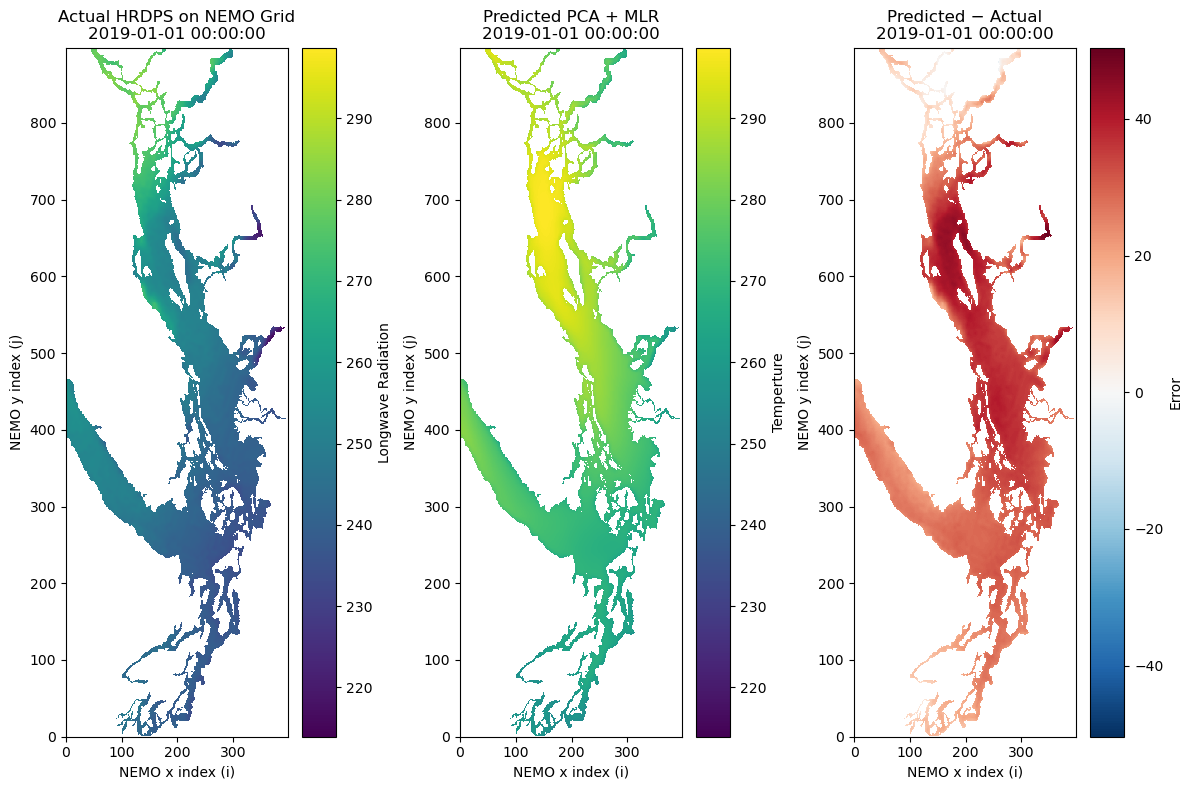

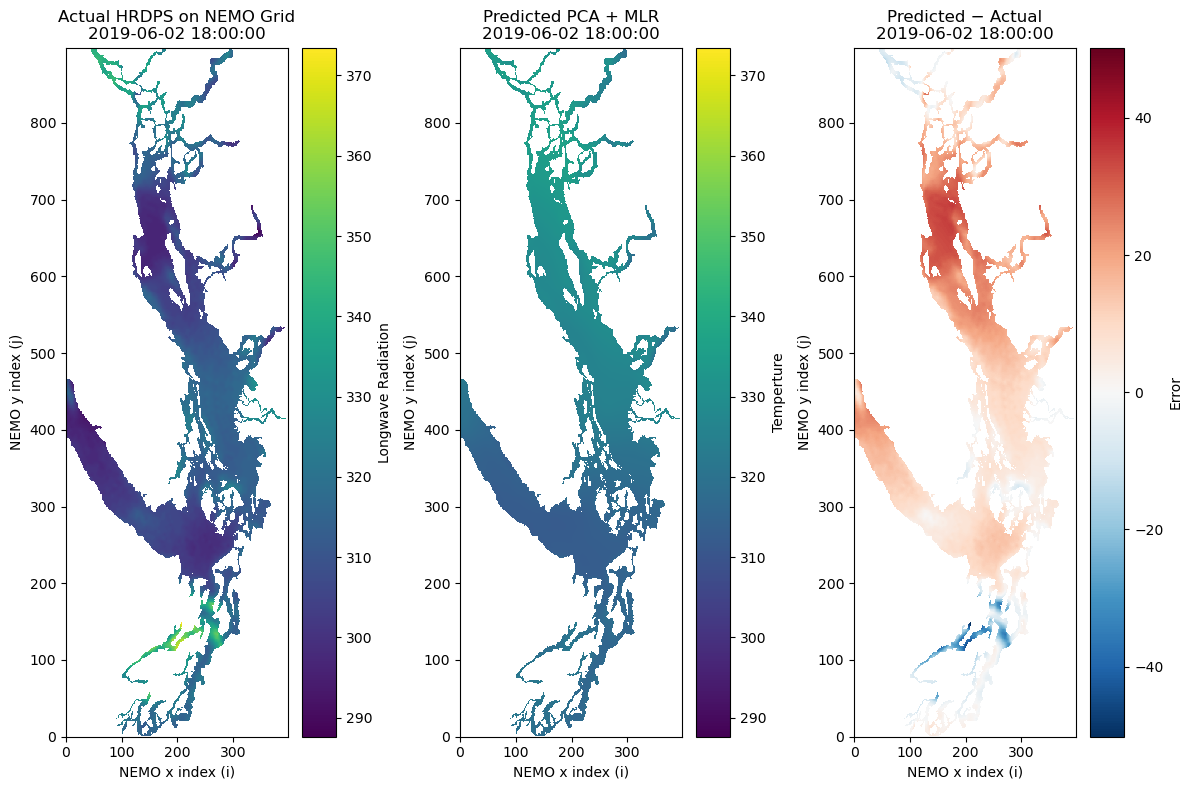

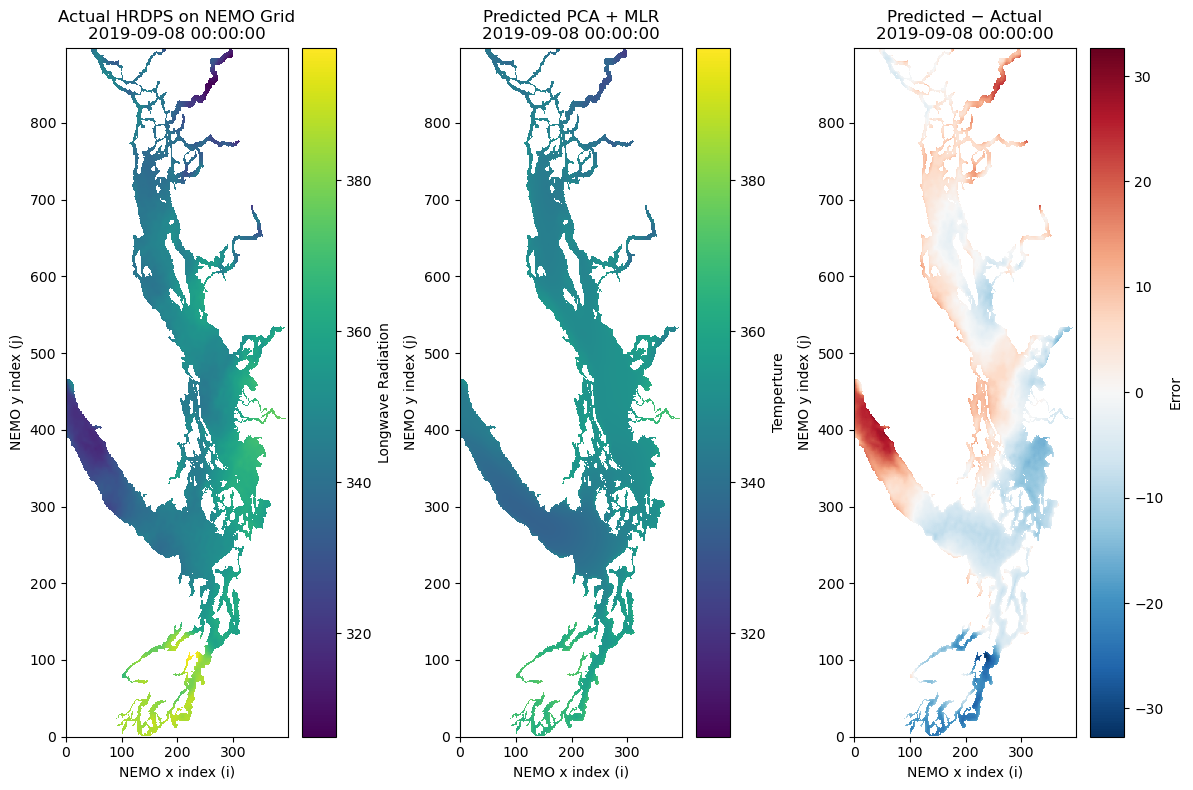

In [44]:
test_times = ds_hrdps_test["time_counter"].values

plot_actual_predicted_error(
    time_index=0,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

plot_actual_predicted_error(
    time_index=1222,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

plot_actual_predicted_error(
    time_index=2000,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

In [45]:
def make_spatial_mean_timeseries(actual_matrix,predicted_matrix,times):
    actual_mean = np.mean(actual_matrix,axis=1)
    predicted_mean = np.mean(predicted_matrix,axis=1)
    timeseries = pd.DataFrame({"actual": actual_mean,"predicted": predicted_mean},index=pd.to_datetime(times))
    timeseries.index.name = "Date"
    return timeseries

In [46]:
val_times = ds_hrdps_val["time_counter"].values
test_times = ds_hrdps_test["time_counter"].values

longwave_radiation_timeseries_val = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_val,
    predicted_matrix=X_hrdps_val_pred,
    times=val_times
)

longwave_radiation_timeseries_test = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_test,
    predicted_matrix=X_hrdps_test_pred,
    times=test_times
)

print(longwave_radiation_timeseries_val.head())
print()
print(longwave_radiation_timeseries_val.tail())
print()
print(longwave_radiation_timeseries_test.head())
print()
print(longwave_radiation_timeseries_test.tail())

                         actual   predicted
Date                                       
2007-01-03 00:00:00  334.159149  328.257965
2007-01-03 03:00:00  333.490051  314.287567
2007-01-03 06:00:00  315.761139  305.185425
2007-01-03 09:00:00  312.443024  309.847412
2007-01-03 12:00:00  328.111115  314.267395

                         actual   predicted
Date                                       
2009-12-31 09:00:00  327.952026  308.041840
2009-12-31 12:00:00  324.691925  299.936646
2009-12-31 15:00:00  327.592987  319.484772
2009-12-31 18:00:00  328.469116  324.035522
2009-12-31 21:00:00  326.405914  328.091858

                         actual   predicted
Date                                       
2019-01-01 00:00:00  247.880005  277.884705
2019-01-01 03:00:00  249.492691  280.997620
2019-01-01 06:00:00  253.045273  281.041595
2019-01-01 09:00:00  257.966858  277.969635
2019-01-01 12:00:00  278.245087  283.842926

                         actual   predicted
Date                         

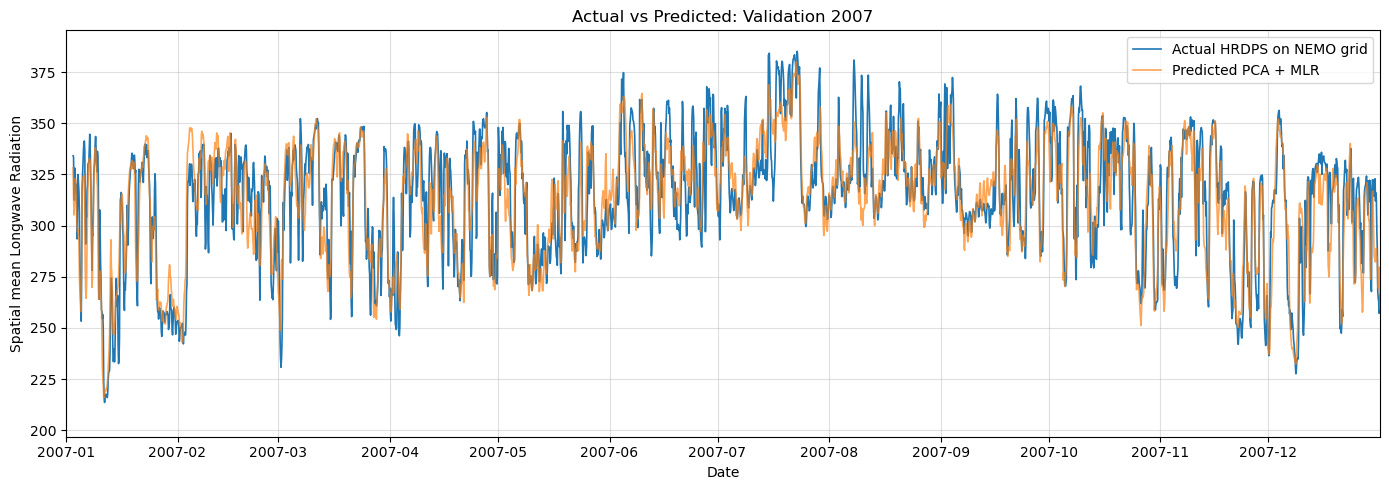

In [47]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(longwave_radiation_timeseries_val.index,longwave_radiation_timeseries_val["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(longwave_radiation_timeseries_val.index,longwave_radiation_timeseries_val["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2007-01-01"),pd.Timestamp("2007-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Longwave Radiation")
ax.set_title("Actual vs Predicted: Validation 2007")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

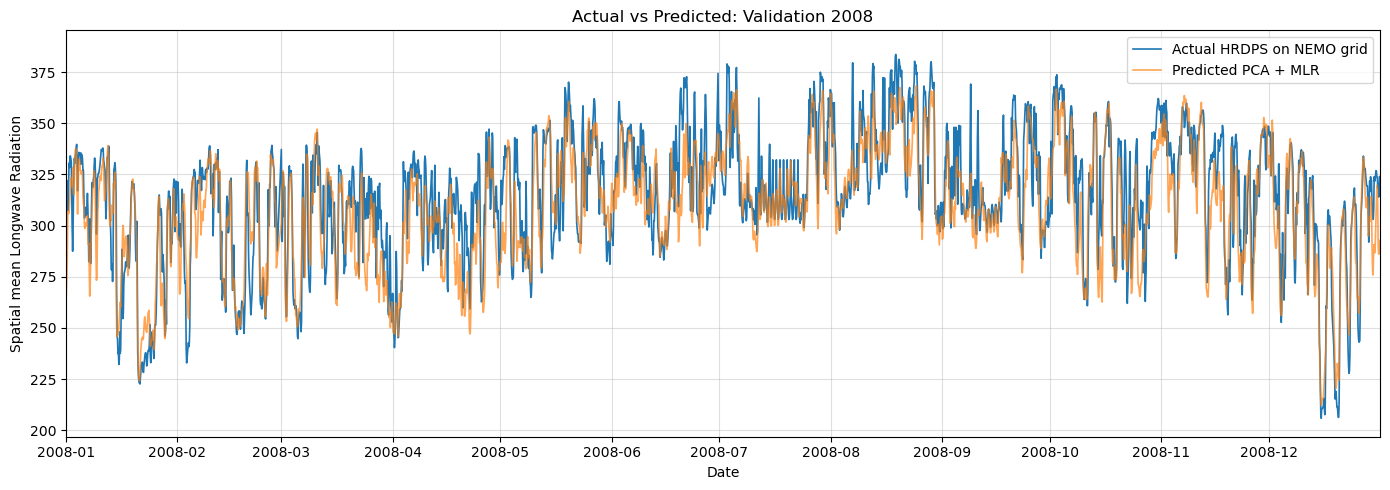

In [48]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(longwave_radiation_timeseries_val.index,longwave_radiation_timeseries_val["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(longwave_radiation_timeseries_val.index,longwave_radiation_timeseries_val["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2008-01-01"),pd.Timestamp("2008-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Longwave Radiation")
ax.set_title("Actual vs Predicted: Validation 2008")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

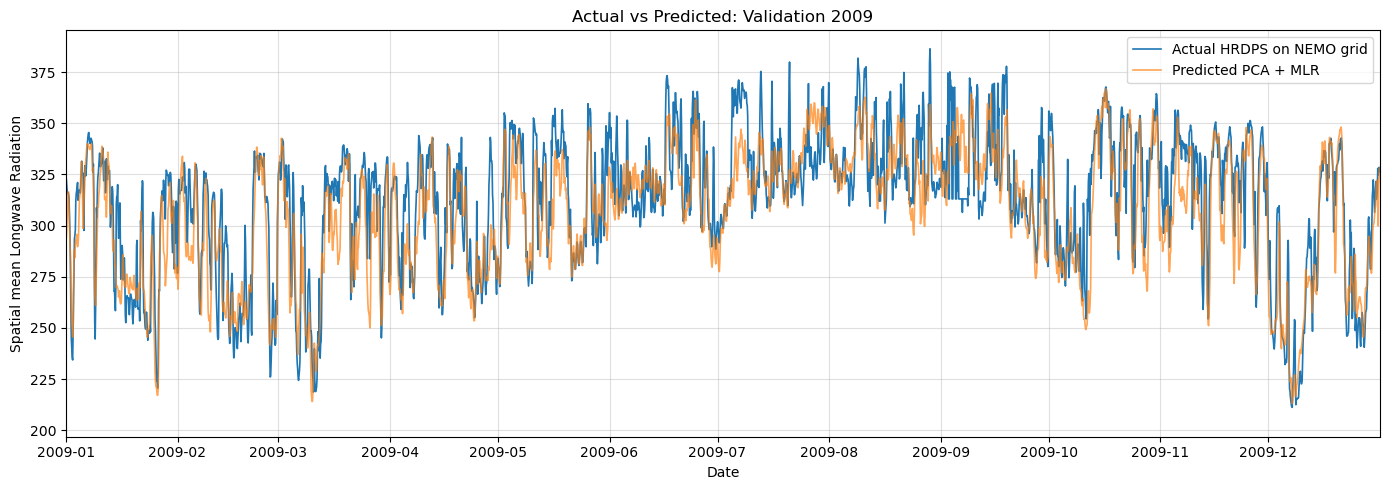

In [49]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(longwave_radiation_timeseries_val.index,longwave_radiation_timeseries_val["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(longwave_radiation_timeseries_val.index,longwave_radiation_timeseries_val["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2009-01-01"),pd.Timestamp("2009-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Longwave Radiation")
ax.set_title("Actual vs Predicted: Validation 2009")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

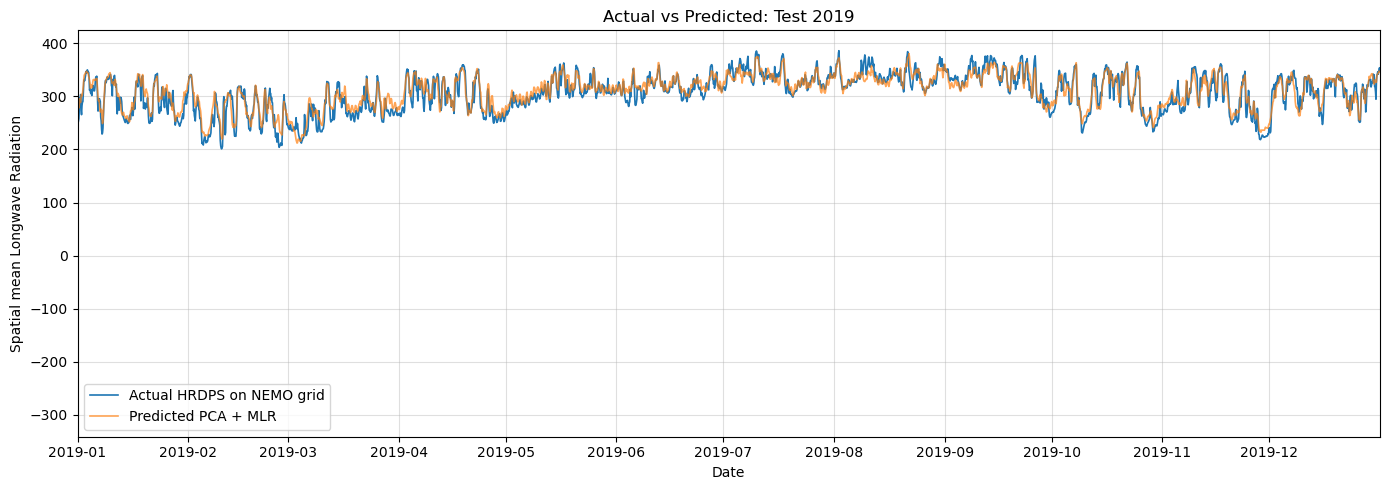

In [50]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(longwave_radiation_timeseries_test.index, longwave_radiation_timeseries_test["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
ax.plot(longwave_radiation_timeseries_test.index, longwave_radiation_timeseries_test["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Longwave Radiation")
ax.set_title("Actual vs Predicted: Test 2019")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

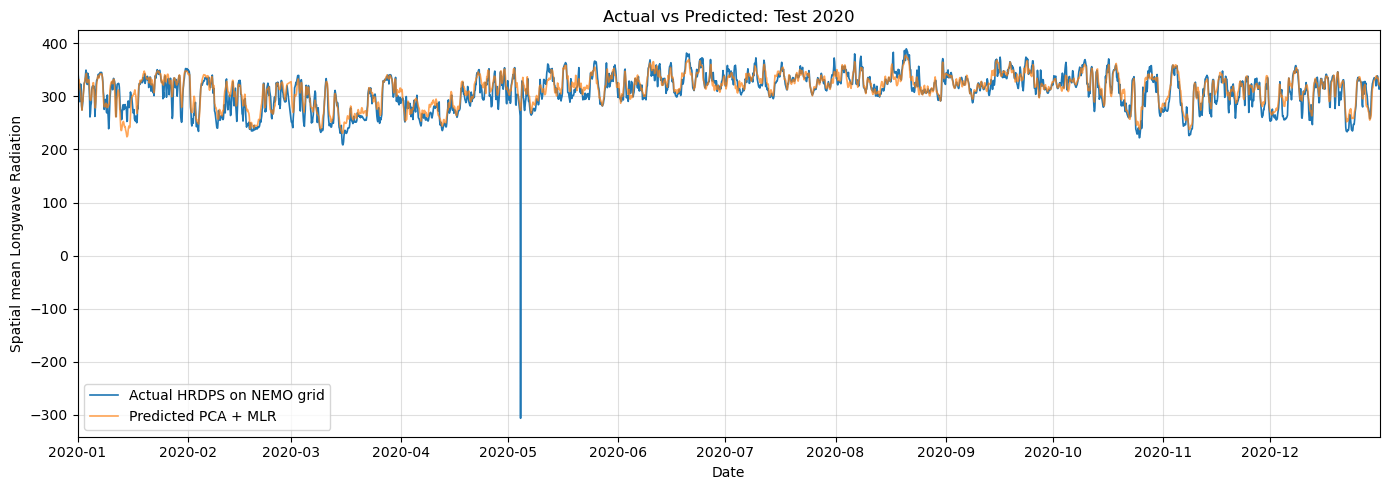

In [51]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(longwave_radiation_timeseries_test.index, longwave_radiation_timeseries_test["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
ax.plot(longwave_radiation_timeseries_test.index, longwave_radiation_timeseries_test["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
ax.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Longwave Radiation")
ax.set_title("Actual vs Predicted: Test 2020")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

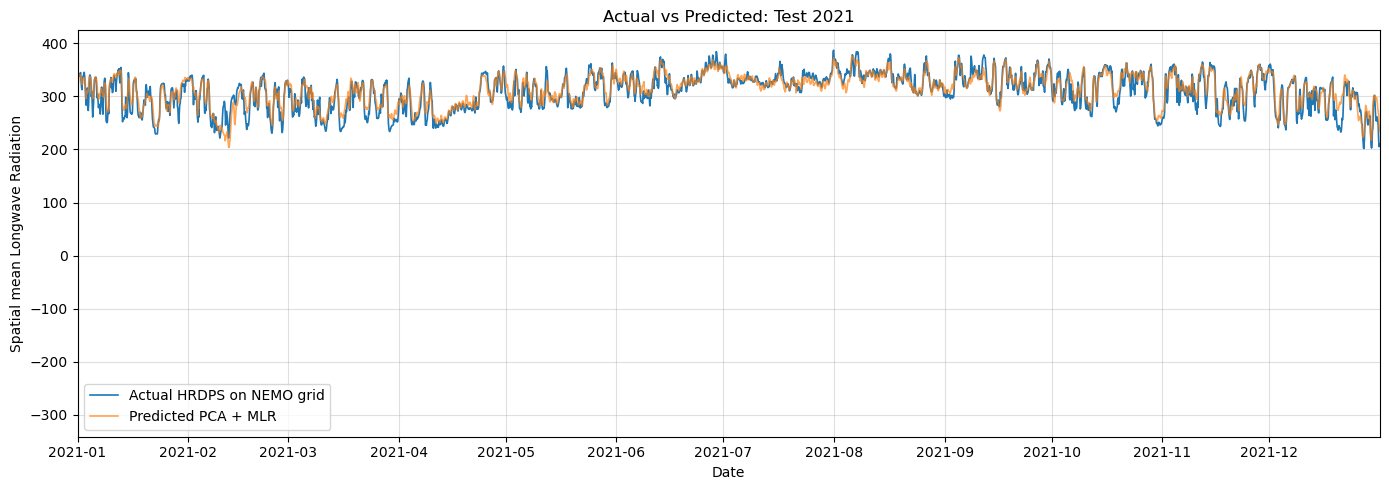

In [52]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(longwave_radiation_timeseries_test.index, longwave_radiation_timeseries_test["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
ax.plot(longwave_radiation_timeseries_test.index, longwave_radiation_timeseries_test["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
ax.set_xlim(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Longwave Radiation")
ax.set_title("Actual vs Predicted: Test 2021")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [53]:
stations = {"Sand Heads": {"j": 426,"i": 293},
    "Halibut Bank": {"j": 503,"i": 261},
    "Sentry Shoal": {"j": 707,"i": 145}}

In [54]:
def find_station_column(station_j, station_i):
    matches = np.where((valid_nemo_j == station_j)& (valid_nemo_i == station_i))[0]
    return int(matches[0])

for station_name, station_info in stations.items():
    column = find_station_column(station_info["j"],station_info["i"])
    stations[station_name]["column"] = column
    print(station_name,"j =", station_info["j"],"i =", station_info["i"],"matrix column =", column)

Sand Heads j = 426 i = 293 matrix column = 44165
Halibut Bank j = 503 i = 261 matrix column = 53329
Sentry Shoal j = 707 i = 145 matrix column = 71870


In [55]:
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)
station_timeseries = {}
station_rmse = {}
station_normalized_rmse = {}

for station_name, station_info in stations.items():
    column = station_info["column"]

    actual = X_hrdps_test[:, column]
    predicted = X_hrdps_test_pred[:, column]

    station_df = pd.DataFrame({"actual": actual,"predicted": predicted},index=test_times)
    station_df.index.name = "Date"
    rmse = np.sqrt(mean_squared_error(station_df["actual"],station_df["predicted"]))
    actual_std = np.std(station_df["actual"],ddof=0)
    normalized_rmse = rmse / actual_std
    station_timeseries[station_name] = station_df
    station_rmse[station_name] = rmse
    station_normalized_rmse[station_name] = normalized_rmse
    print(f"{station_name} RMSE: {rmse:.4f} ")
    print(f"{station_name} Normalized RMSE: {normalized_rmse:.4f} ({normalized_rmse * 100:.2f}%)")

Sand Heads RMSE: 20.8697 
Sand Heads Normalized RMSE: 0.5409 (54.09%)
Halibut Bank RMSE: 20.9677 
Halibut Bank Normalized RMSE: 0.5459 (54.59%)
Sentry Shoal RMSE: 21.6061 
Sentry Shoal Normalized RMSE: 0.5446 (54.46%)


In [56]:
station_rmse_table = pd.DataFrame({"Station": list(station_rmse.keys()),"RMSE": list(station_rmse.values()),"Normalized_RMSE": list(station_normalized_rmse.values())})
station_rmse_table["Normalized_RMSE_Percent"] = station_rmse_table["Normalized_RMSE"] * 100
average_station_rmse = station_rmse_table["RMSE"].mean()
average_station_normalized_rmse = station_rmse_table["Normalized_RMSE"].mean()
print(station_rmse_table.to_string(index=False))
print(f"\nAverage RMSE across the three stations: {average_station_rmse:.4f}")
print(f"Average normalized RMSE across the three stations: {average_station_normalized_rmse:.4f} ({average_station_normalized_rmse * 100:.2f}%)")

     Station      RMSE  Normalized_RMSE  Normalized_RMSE_Percent
  Sand Heads 20.869725         0.540876                54.087563
Halibut Bank 20.967702         0.545934                54.593366
Sentry Shoal 21.606113         0.544579                54.457921

Average RMSE across the three stations: 21.1478
Average normalized RMSE across the three stations: 0.5438 (54.38%)


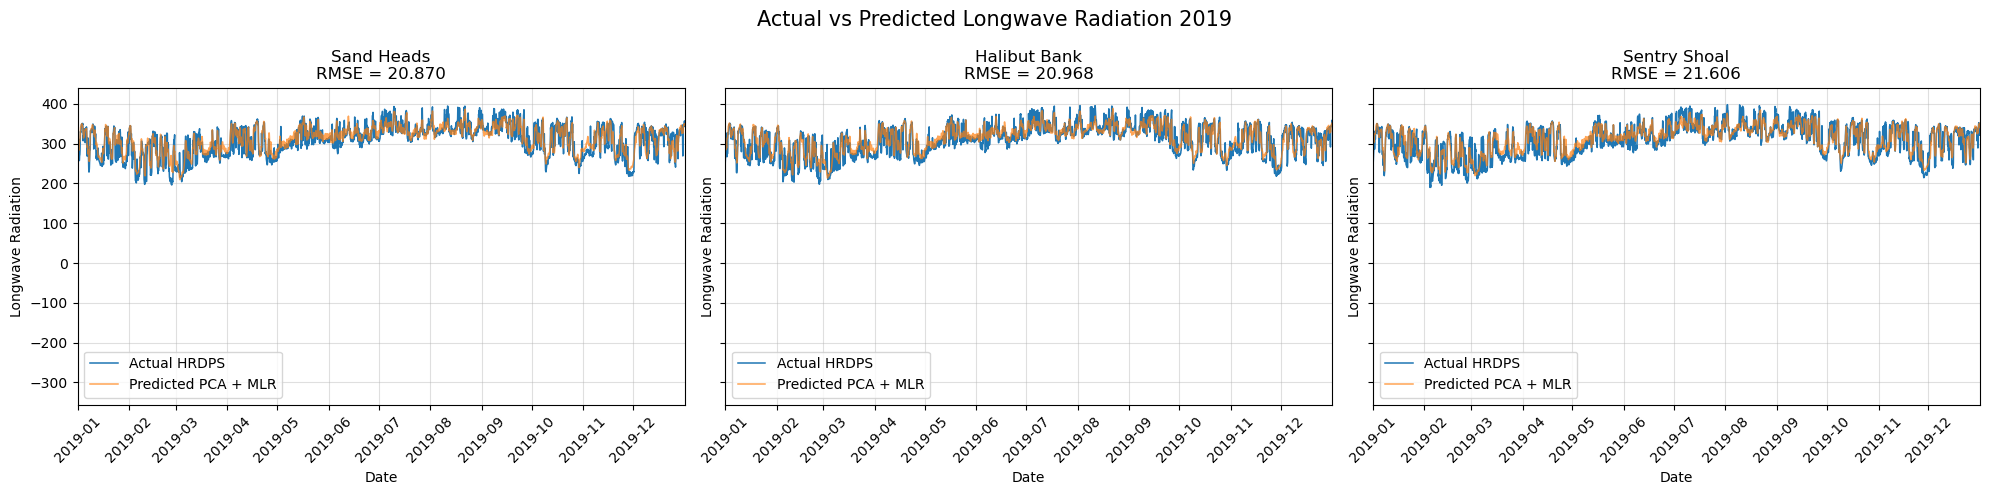

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, (station_name, station_df) in zip(axes, station_timeseries.items()):
    ax.plot(station_df.index, station_df["actual"], label="Actual HRDPS", linewidth=1.1)
    ax.plot(station_df.index, station_df["predicted"], label="Predicted PCA + MLR", linewidth=1.1, alpha=0.7)
    ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
    ax.set_xlabel("Date")
    ax.set_ylabel("Longwave Radiation")
    ax.set_title(f"{station_name}\nRMSE = {station_rmse[station_name]:.3f}")
    ax.legend()
    ax.grid(True, alpha=0.4)
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Actual vs Predicted Longwave Radiation 2019", fontsize=15)

plt.tight_layout()
plt.show()

In [58]:
X_hrdps_train_pred = inverse_from_selected_hrdps_pcs(hrdps_train_scores_pred,pca_hrdps,n_hrdps_pcs)

print("Predicted training field shape:", X_hrdps_train_pred.shape)
print("Predicted validation field shape:", X_hrdps_val_pred.shape)
print("Predicted test field shape:", X_hrdps_test_pred.shape)

Predicted training field shape: (26280, 81383)
Predicted validation field shape: (8744, 81383)
Predicted test field shape: (8760, 81383)


In [59]:
train_times = pd.to_datetime(ds_hrdps_train["time_counter"].values)
val_times = pd.to_datetime(ds_hrdps_val["time_counter"].values)
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)

predicted_split_data = {
    "Validation": {"years": validation_years, "times": val_times, "values": X_hrdps_val_pred},
    "Training": {"years": train_years, "times": train_times, "values": X_hrdps_train_pred},
    "Test": {"years": test_years, "times": test_times, "values": X_hrdps_test_pred}
}

In [60]:
monthly_records = []

for split_name, split_data in predicted_split_data.items():
    predicted_spatial_mean = np.mean(split_data["values"],axis=1)
    predicted_timeseries = pd.DataFrame({"Predicted": predicted_spatial_mean},index=split_data["times"])
    predicted_timeseries.index.name = "Date"
    split_monthly_averages = predicted_timeseries.groupby([predicted_timeseries.index.year,predicted_timeseries.index.month])["Predicted"].mean()

    for (year, month), monthly_average in split_monthly_averages.items():
        monthly_records.append({"Year": int(year),"Month": int(month),"Predicted_Monthly_Average": float(monthly_average),"Split": split_name})

predicted_monthly_averages = pd.DataFrame(monthly_records)
predicted_monthly_averages = predicted_monthly_averages.sort_values(["Year","Month"]).reset_index(drop=True)

In [61]:
predicted_monthly_table = predicted_monthly_averages.pivot(index="Year",columns="Month",values="Predicted_Monthly_Average")
predicted_monthly_table = predicted_monthly_table.reindex(columns=range(1,13))
predicted_monthly_table.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

print("Predicted monthly average Longwave Radiation table:")
print(predicted_monthly_table.round(2).to_string())

Predicted monthly average Longwave Radiation table:
         Jan     Feb     Mar     Apr     May     Jun     Jul     Aug     Sep     Oct     Nov     Dec
Year                                                                                                
2007  288.17  313.03  311.75  307.38  305.81  328.85  335.71  325.62  317.93  317.46  301.83  297.38
2008  291.70  297.58  295.22  291.90  315.81  320.01  323.68  335.30  314.67  312.61  319.00  289.74
2009  289.27  283.00  288.38  292.60  308.58  319.88  329.37  330.70  324.47  311.00  314.07  277.43
2010  321.92  303.22  305.42  304.07  312.41  324.02  317.62  326.32  336.50  317.33  304.80  304.74
2011  302.14  284.57  307.24  294.93  314.35  325.24  330.92  322.06  326.00  314.65  300.52  288.08
2012  296.33  299.60  300.03  313.00  306.86  331.97  330.72  330.24  311.86  316.26  315.64  306.57
2013  293.78  301.52  297.93  299.80  317.14  330.58  318.62  339.90  334.22  301.47  305.41  293.01
2014  298.27  283.41  306.66  309.68  3

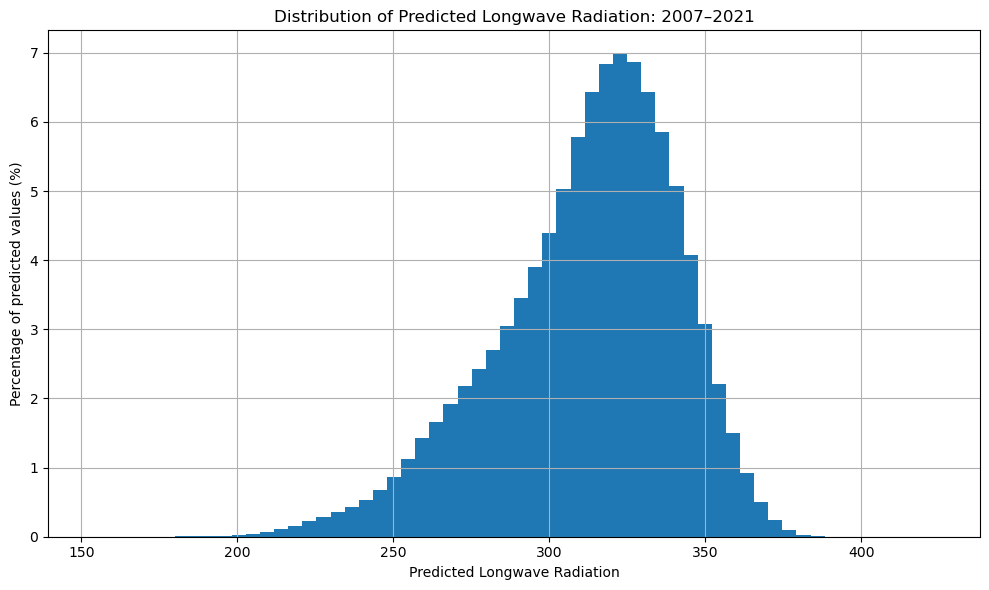

In [62]:
global_predicted_min = min(float(np.min(split_data["values"])) for split_data in predicted_split_data.values())
global_predicted_max = max(float(np.max(split_data["values"])) for split_data in predicted_split_data.values())
histogram_bins = np.linspace(global_predicted_min,global_predicted_max,61)
all_year_histogram_counts = np.zeros(len(histogram_bins) - 1,dtype=np.int64)

for split_data in predicted_split_data.values():
    split_counts, _ = np.histogram(split_data["values"],bins=histogram_bins)
    all_year_histogram_counts += split_counts

all_year_histogram_percentage = 100 * all_year_histogram_counts / all_year_histogram_counts.sum()

plt.figure(figsize=(10,6))
plt.stairs(all_year_histogram_percentage,histogram_bins,fill=True)
plt.xlabel("Predicted Longwave Radiation")
plt.ylabel("Percentage of predicted values (%)")
plt.title("Distribution of Predicted Longwave Radiation: 2007–2021")
plt.tight_layout()
plt.grid(True)
plt.show()

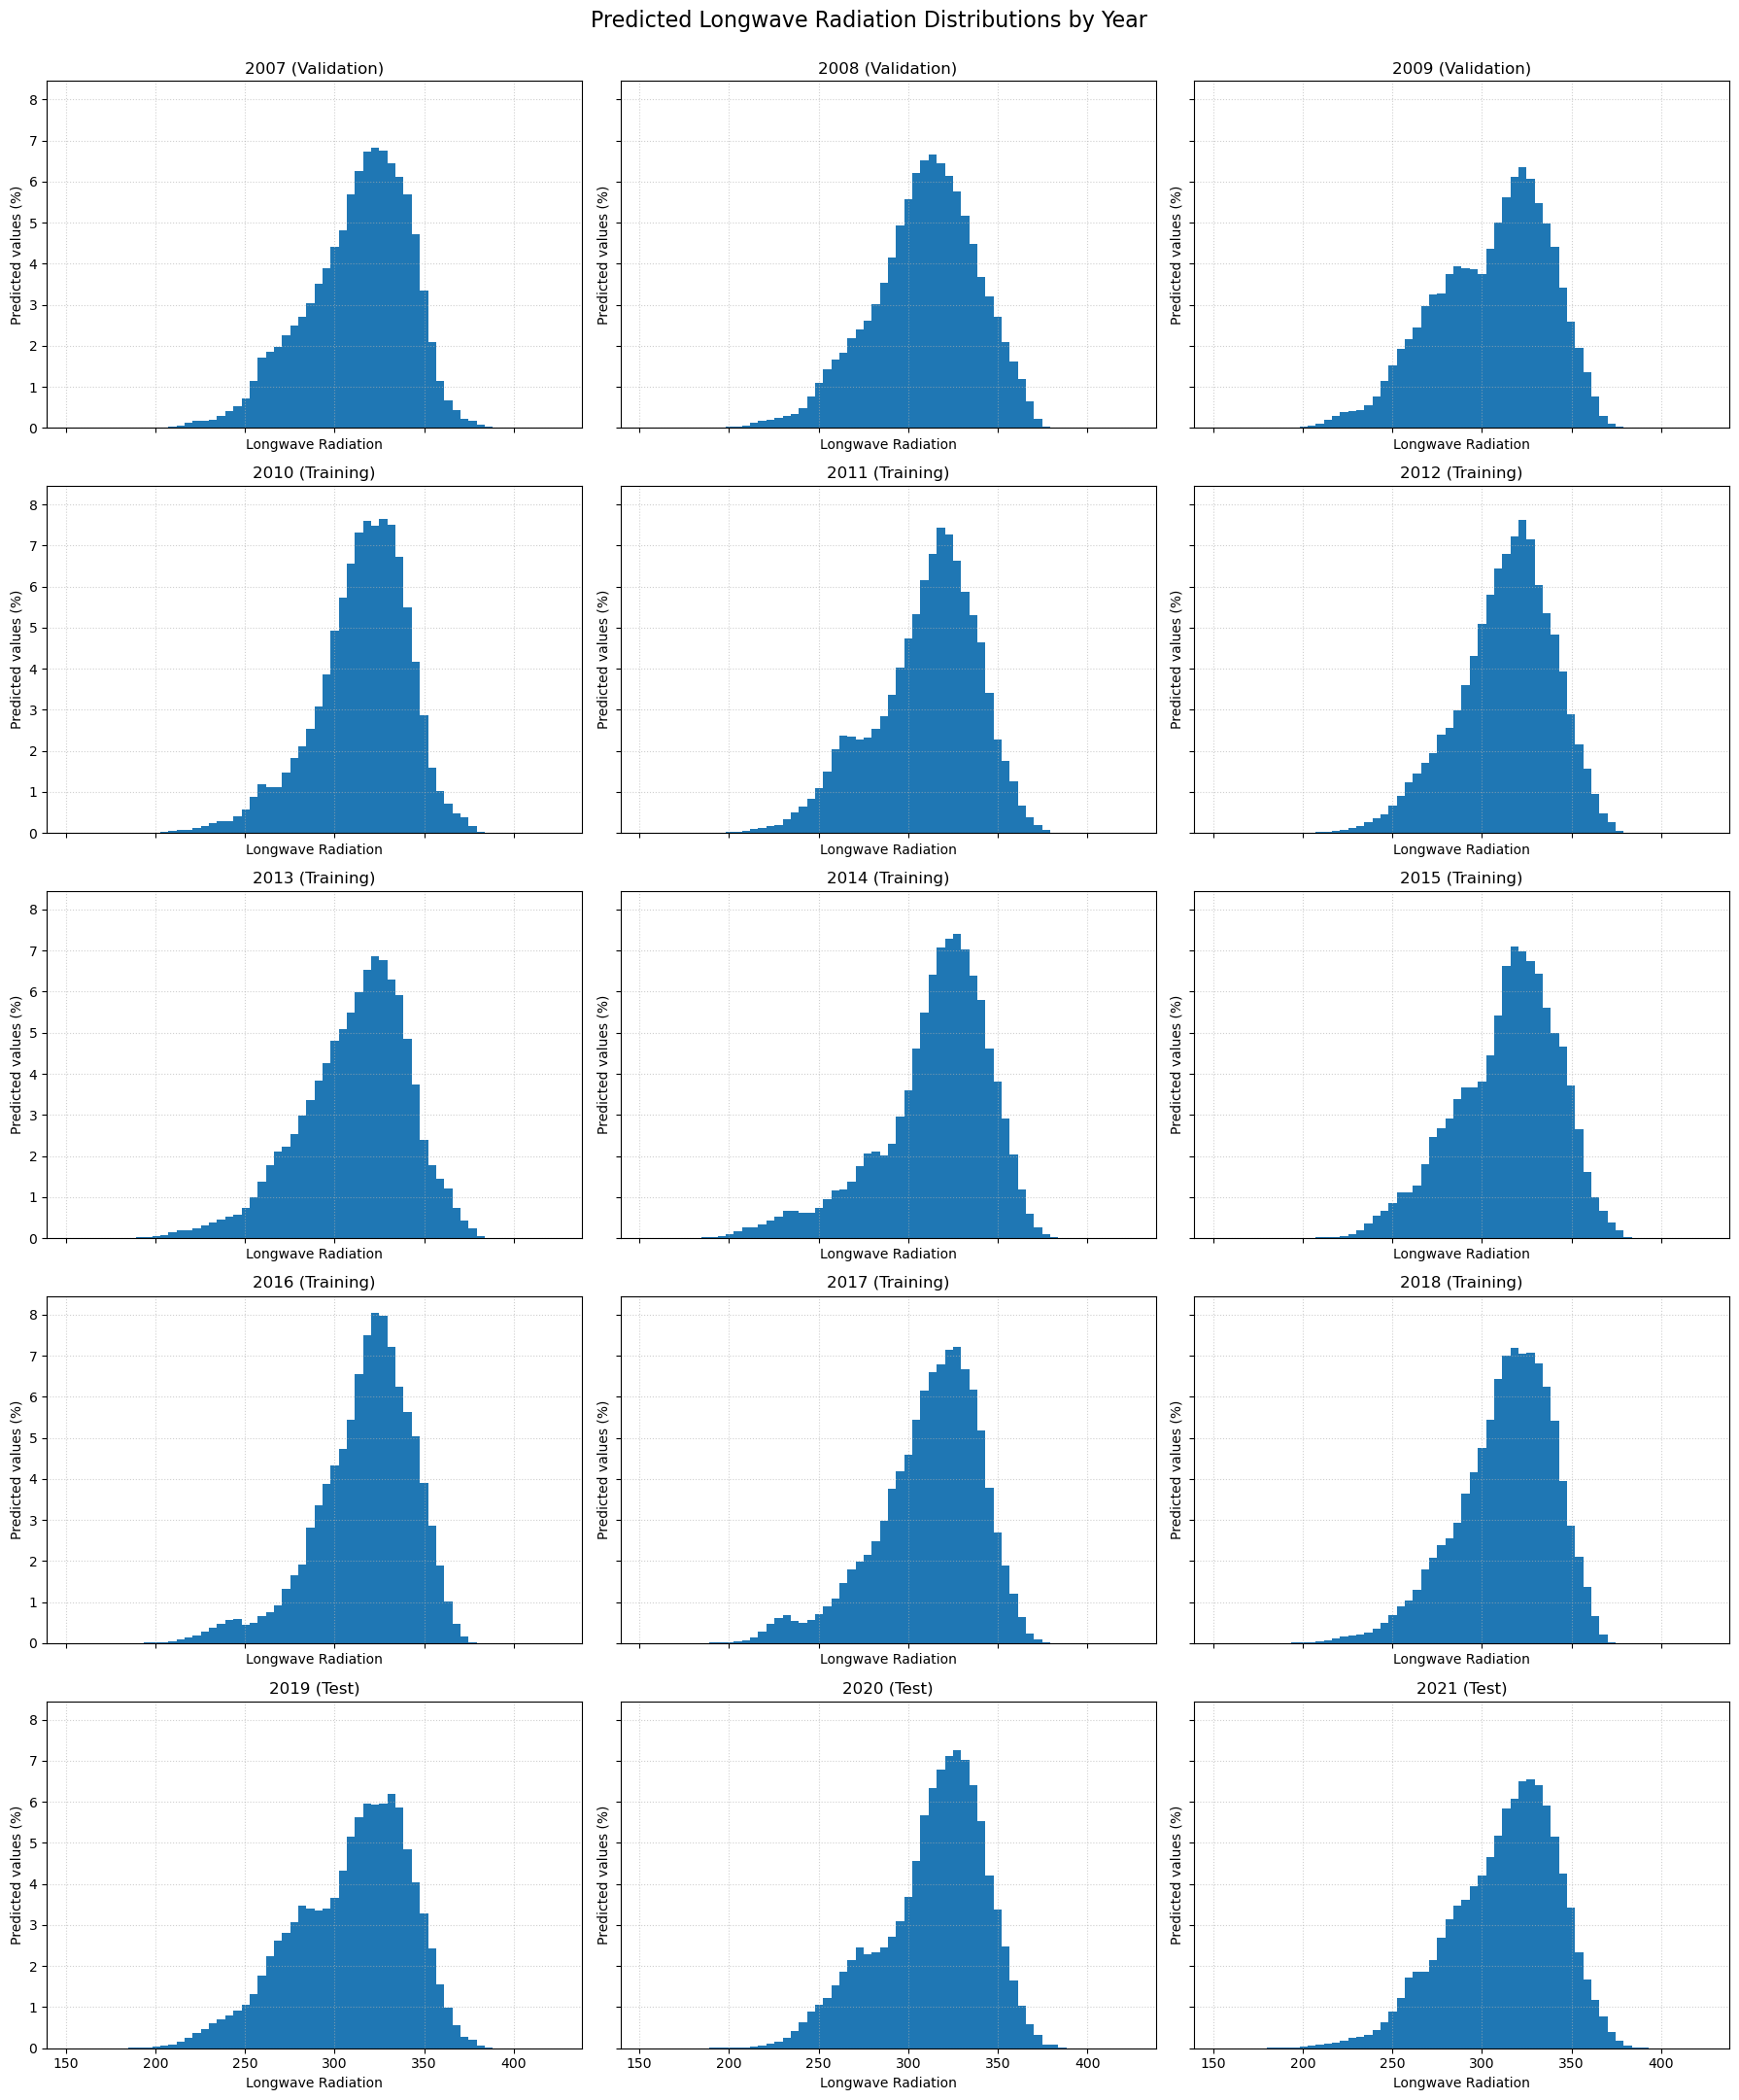

In [63]:
fig, axes = plt.subplots(5,3,figsize=(18,22),sharex=True,sharey=True)
axes = axes.ravel()

for ax, year in zip(axes,range(2007,2022)):
    year_split_name = None
    year_split_data = None

    for split_name, split_data in predicted_split_data.items():
        if year in split_data["years"]:
            year_split_name = split_name
            year_split_data = split_data
            break

    year_positions = np.where(year_split_data["times"].year == year)[0]

    if len(year_positions) == 0:
        ax.set_title(f"{year}: No data")
        continue

    year_predictions = year_split_data["values"][year_positions[0]:year_positions[-1] + 1]
    year_histogram_counts, _ = np.histogram(year_predictions,bins=histogram_bins)
    year_histogram_percentage = 100 * year_histogram_counts / year_histogram_counts.sum()

    ax.stairs(year_histogram_percentage,histogram_bins,fill=True)
    ax.set_title(f"{year} ({year_split_name})")
    ax.set_xlabel("Longwave Radiation")
    ax.set_ylabel("Predicted values (%)")
    ax.grid(True, linestyle=':', alpha=0.6)

fig.suptitle("Predicted Longwave Radiation Distributions by Year",fontsize=16)
plt.tight_layout(rect=[0,0,1,0.98])
plt.show()

Actual 2008 shape: (2920, 81383)
Predicted 2008 shape: (2920, 81383)
Number of 2008 timestamps: 2920
Number of selected spatial points: 16277
Mean RMSE across selected points: 23.197714
Minimum RMSE: 21.099047
Maximum RMSE: 30.688622


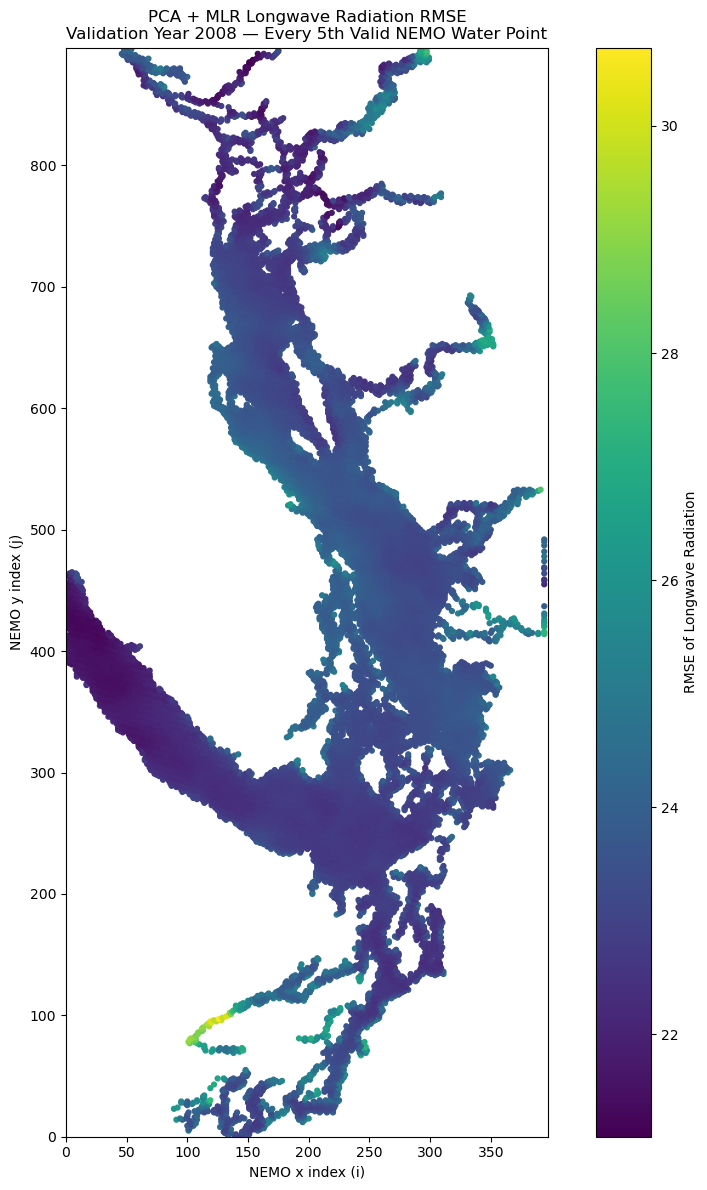

 Matrix_Column  NEMO_j  NEMO_i      RMSE
             0       1     134 24.375570
             5       1     139 23.491508
            10       1     144 22.961914
            15       1     149 23.556786
            20       2     133 24.055674
            25       2     140 23.187498
            30       2     145 22.973665
            35       2     151 23.515081
            40       3     131 23.664108
            45       3     136 23.648205
            50       3     145 23.095301
            55       3     150 23.222630
            60       4     130 23.311157
            65       4     135 23.816607
            70       4     145 23.346790
            75       4     150 23.126663
            80       5     101 25.054884
            85       5     133 23.271135
            90       5     147 23.198620
            95       5     152 22.996431


In [64]:
validation_year = 2008
spatial_step = 5

val_times = pd.to_datetime(ds_hrdps_val["time_counter"].values)
year_time_mask = val_times.year == validation_year

if not np.any(year_time_mask):
    raise ValueError(f"No validation data found for {validation_year}.")

X_actual_2008 = X_hrdps_val[year_time_mask]
X_predicted_2008 = X_hrdps_val_pred[year_time_mask]

print("Actual 2008 shape:", X_actual_2008.shape)
print("Predicted 2008 shape:", X_predicted_2008.shape)
print("Number of 2008 timestamps:", np.sum(year_time_mask))

if X_actual_2008.shape != X_predicted_2008.shape:
    raise ValueError("Actual and predicted validation matrices do not have matching shapes.")

selected_columns = np.arange(0, X_actual_2008.shape[1], spatial_step)

actual_selected = X_actual_2008[:, selected_columns]
predicted_selected = X_predicted_2008[:, selected_columns]

rmse_every_5th_point = np.sqrt(
    np.nanmean(
        (predicted_selected - actual_selected) ** 2,
        axis=0
    )
)

selected_nemo_j = valid_nemo_j[selected_columns]
selected_nemo_i = valid_nemo_i[selected_columns]

print("Number of selected spatial points:", len(selected_columns))
print("Mean RMSE across selected points:", np.nanmean(rmse_every_5th_point))
print("Minimum RMSE:", np.nanmin(rmse_every_5th_point))
print("Maximum RMSE:", np.nanmax(rmse_every_5th_point))

fig, ax = plt.subplots(figsize=(10, 12))

scatter = ax.scatter(
    selected_nemo_i,
    selected_nemo_j,
    c=rmse_every_5th_point,
    cmap="viridis",
    s=12,
    marker="o"
)

colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("RMSE of Longwave Radiation")

ax.set_xlabel("NEMO x index (i)")
ax.set_ylabel("NEMO y index (j)")
ax.set_title(
    "PCA + MLR Longwave Radiation RMSE\n"
    "Validation Year 2008 — Every 5th Valid NEMO Water Point"
)

ax.set_xlim(0, water_mask.shape[1] - 1)
ax.set_ylim(0, water_mask.shape[0] - 1)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

rmse_every_5th_point_table = pd.DataFrame(
    {
        "Matrix_Column": selected_columns,
        "NEMO_j": selected_nemo_j,
        "NEMO_i": selected_nemo_i,
        "RMSE": rmse_every_5th_point
    }
)

print(rmse_every_5th_point_table.head(20).to_string(index=False))